## Apply PCA and t-SNE for Dimensionality Reduction 

In [7]:
#import libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [8]:
#2) LOad Dataset 
digits= load_digits()
x=digits.data
y=digits.data
print(f"Dataset shape :{x.shape}")

Dataset shape :(1797, 64)


In [9]:
#3) Standardize data 
Scaler=StandardScaler()
x_scaled =Scaler.fit_transform


Explained variance ratio [0.12033916 0.09561054]
Total variance retained: 0.21594970500832786


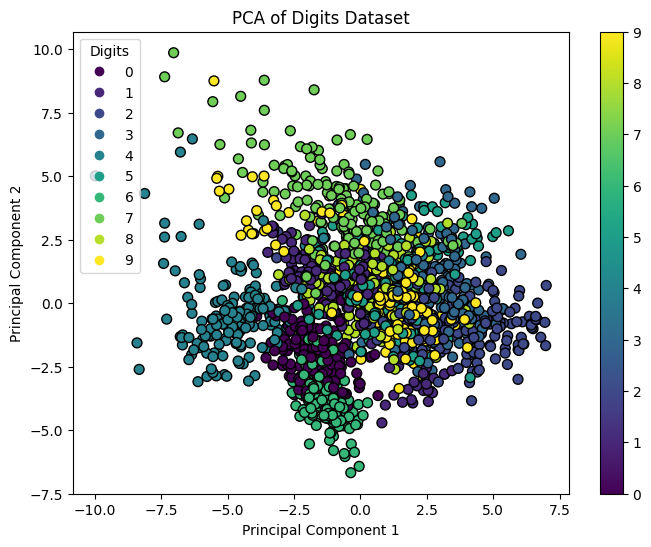

In [17]:
#4) Apply PCA 
pca=PCA(n_components=2)
x_scaled = Scaler.fit_transform(x)
x_pca = pca.fit_transform(x_scaled)
print("Explained variance ratio", pca.explained_variance_ratio_)
print("Total variance retained:", np.sum(pca.explained_variance_ratio_))

plt.figure(figsize=(8, 6))
scatter = plt.scatter(x_pca[:,0], x_pca[:,1], c=digits.target, cmap='viridis', edgecolor='k', s=50)
plt.legend(*scatter.legend_elements(), title="Digits")
plt.title("PCA of Digits Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter)
plt.show()

c:\data-Scientist\.venv\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE completed.


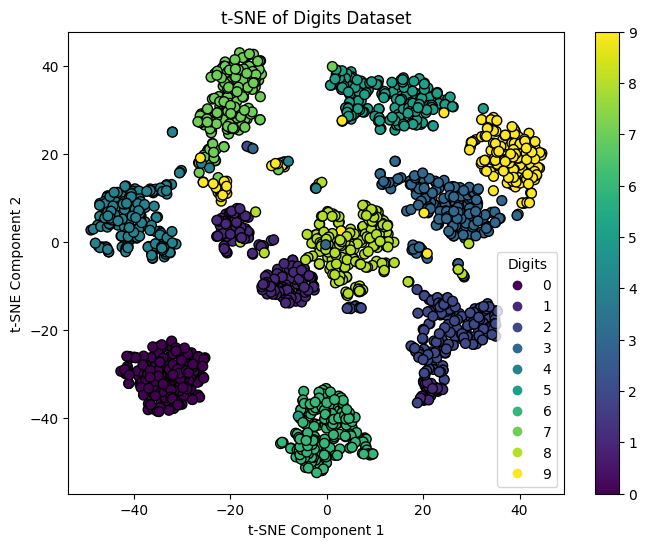

In [19]:
# 5) Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30,n_iter=1000, random_state=42)
x_tsne = tsne.fit_transform(x_scaled)
print("t-SNE completed.")   
plt.figure(figsize=(8, 6))
scatter = plt.scatter(x_tsne[:,0], x_tsne[:,1], c=digits.target, cmap='viridis', edgecolor='k', s=50)
plt.legend(*scatter.legend_elements(), title="Digits")
plt.title("t-SNE of Digits Dataset")
plt.xlabel("t-SNE Component 1") 
plt.ylabel("t-SNE Component 2")
plt.colorbar(scatter)
plt.show()

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
mlflow.set_experiment("Iris-LogisticRegression")
with mlflow.start_run():
    C = 1.0
    max_iter = 200
    mlflow.log_param("C", C)
    mlflow.log_param("max_iter", max_iter)
    model = LogisticRegression(C=C, max_iter=max_iter)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.sklearn.log_model(model, "model")

    print(f"Accuracy: {accuracy}")


2025/08/10 14:45:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/08/10 14:45:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Accuracy: 1.0
